In [25]:
# importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [26]:
# Load the dataset
df = pd.read_csv('../../data/Activity2MLR.csv')

In [27]:
# display the dataset
print(df.head())

   age  experience  income
0   25           1   30450
1   30           3   35670
2   47           2   31580
3   32           5   40130
4   43          10   47830


In [28]:
#check the missed values
print(df.isnull().sum())

age           0
experience    0
income        0
dtype: int64


In [29]:
# Decriptive statistics
print(df.describe())

             age  experience        income
count  20.000000   20.000000     20.000000
mean   39.650000    6.200000  40735.500000
std    10.027725    4.124382   8439.797625
min    23.000000    1.000000  27840.000000
25%    31.500000    3.750000  35452.500000
50%    40.000000    5.000000  40190.000000
75%    47.000000    9.000000  45390.000000
max    58.000000   17.000000  63600.000000


In [30]:
# prepare data
X = df[['age', 'experience']]
y = df['income']

In [31]:
# Train the model
model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ -99.2,2162.4]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['age','experience']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.126e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2


In [32]:
# prediction
y_pred = model.predict(X)

In [33]:
# model coefficients
print('\n Intercept: ', model.intercept_)
print('\n Age Coefficients: ', model.coef_[0])
print('\n Experience Coefficient: ', model.coef_[1])


 Intercept:  31261.689854101278

 Age Coefficients:  -99.19535546105377

 Experience Coefficient:  2162.404191924113


In [34]:
# model evaluation
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print('\n Root Mean Squared Error: ', rmse)
print('\n R-squared Score: ', r2)


 Root Mean Squared Error:  1238.3997653077047

 R-squared Score:  0.9773361310180797


In [35]:
# Example prediction
new_person = [[35, 8]]
predicted_income = model.predict(new_person)

print('\n Predicted income for a 35-year-old with 8 years of experience: ', predicted_income[0])


 Predicted income for a 35-year-old with 8 years of experience:  45089.0859483573


/workspaces/DataMining/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


/workspaces/DataMining/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


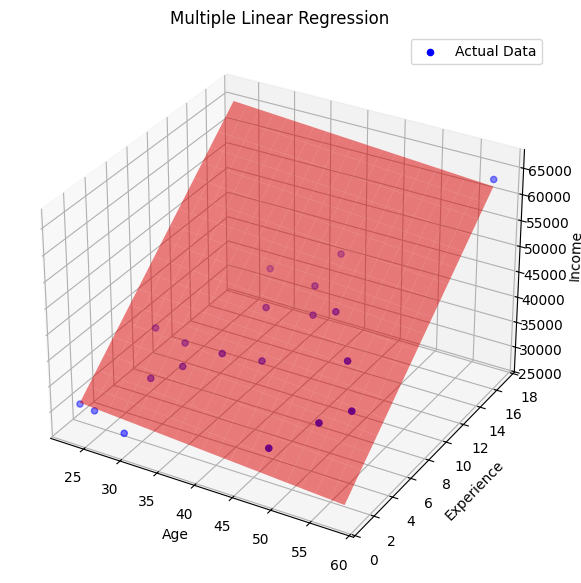

In [37]:
# Visualization
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# scatterplot
ax.scatter(X['age'], X['experience'], y, c='blue', marker='o', label='Actual Data')

# create mesh grid
age_range = np.linspace(X['age'].min(), X['age'].max(), 20)
experience_range = np.linspace(X['experience'].min(), X['experience'].max(), 20)

age_mesh, exp_mesh = np.meshgrid(age_range, experience_range)

# predicted income
income_pred = model.predict(np.c_[age_mesh.ravel(), exp_mesh.ravel()]).reshape(age_mesh.shape)

# regression plan
ax.plot_surface(age_mesh, exp_mesh, income_pred, alpha=0.5, color='red')

#labels
ax.set_xlabel('Age')
ax.set_ylabel('Experience')
ax.set_zlabel('Income')
plt.legend()
ax.set_title('Multiple Linear Regression')

plt.show()